# Model Building

**Models**: Logistic Regression, Decision Tree, Random Forest, SVC and KNN

### 1) Imports

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix,classification_report)
from imblearn.over_sampling import SMOTE
from sklearn.inspection import permutation_importance
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

### 2) Load Cleaned Data

In [20]:
df = pd.read_csv('data.csv')
print(f" Shape: {df.shape}")
df.head()

 Shape: (3500, 17)


,age,sex,bmi,systolic_pressure,diastolic_pressure,glucose,hba1c,cholesterol,hdl_cholesterol,ldl_cholesterol,triglycerides,smoking,physical_activity,family_history_diabetes,family_history_hypertension,diabetes_risk,hypertension_risk
0,75,1,29.8,135,81,105,5.0,181.3,68.9,99.1,66.5,0,7,0,0,0,0
1,48,0,31.4,98,62,69,4.0,238.4,57.3,106.2,374.5,0,7,0,1,0,0
2,58,1,25.5,129,79,82,4.2,173.8,60.2,93.3,101.3,0,0,0,0,0,0
3,27,0,28.7,110,66,82,5.0,154.9,52.8,80.1,110.2,0,0,1,1,0,0
4,50,0,32.0,143,84,96,4.8,193.4,46.2,131.1,80.7,0,1,1,1,0,1


### 3) Prepare Features and Target

In [21]:
base_features = ['age', 'sex', 'bmi', 'systolic_pressure', 'diastolic_pressure',
                 'glucose', 'hba1c', 'cholesterol', 'hdl_cholesterol', 
                 'ldl_cholesterol', 'triglycerides', 'smoking', 
                 'physical_activity', 'family_history_diabetes', 'family_history_hypertension']

# Features de interação
df['bmi_smoking'] = df['bmi'] * df['smoking']
df['age_family_diabetes'] = df['age'] * df['family_history_diabetes']
df['age_family_hypertension'] = df['age'] * df['family_history_hypertension']
df['glucose_cholesterol'] = df['glucose'] * df['cholesterol'] / 1000
df['bmi_physical'] = df['bmi'] * (2 - df['physical_activity'])
df['glucose_hba1c'] = df['glucose'] * df['hba1c'] / 100
df['hdl_ldl_ratio'] = df['hdl_cholesterol'] / (df['ldl_cholesterol'] + 1)
df['systolic_diastolic'] = df['systolic_pressure'] * df['diastolic_pressure'] / 1000
df['triglycerides_hdl_ratio'] = df['triglycerides'] / (df['hdl_cholesterol'] + 1)

# Features categóricas
df['bmi_obese'] = (df['bmi'] >= 30).astype(int)
df['bp_high'] = (df['systolic_pressure'] >= 130).astype(int)
df['glucose_high'] = (df['glucose'] >= 100).astype(int)
df['cholesterol_high'] = (df['cholesterol'] >= 200).astype(int)
df['age_senior'] = (df['age'] >= 60).astype(int)
df['hba1c_prediabetic'] = (df['hba1c'] >= 5.7).astype(int)
df['hdl_low'] = (df['hdl_cholesterol'] < 40).astype(int)
df['triglycerides_high'] = (df['triglycerides'] >= 200).astype(int)

interaction_features = ['bmi_smoking', 'age_family_diabetes', 'age_family_hypertension',
                        'glucose_cholesterol', 'bmi_physical', 'glucose_hba1c',
                        'hdl_ldl_ratio', 'systolic_diastolic', 'triglycerides_hdl_ratio']
categorical_features = ['bmi_obese', 'bp_high', 'glucose_high', 
                        'cholesterol_high', 'age_senior', 'hba1c_prediabetic',
                        'hdl_low', 'triglycerides_high']

all_features = base_features + interaction_features + categorical_features

X = df[all_features].copy()
y_diabetes = df['diabetes_risk']
y_hypertension = df['hypertension_risk']

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"Targets:")
print(f"-Diabetes: {y_diabetes.sum()} positives ({y_diabetes.mean()*100:.1f}%)")
print(f"-Hypertension: {y_hypertension.sum()} positives ({y_hypertension.mean()*100:.1f}%)")

# FIXED: Single split to keep X and both targets aligned
X_train, X_test, y_diab_train, y_diab_test, y_hyp_train, y_hyp_test = train_test_split(
    X, y_diabetes, y_hypertension, test_size=0.2, random_state=67, stratify=y_diabetes
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

# Feature scaling

numeric_features = ['age', 'bmi', 'systolic_pressure', 'diastolic_pressure',
                    'glucose', 'hba1c', 'cholesterol', 'hdl_cholesterol',
                    'ldl_cholesterol', 'triglycerides',
                    'bmi_smoking', 'age_family_diabetes', 'age_family_hypertension',
                    'glucose_cholesterol', 'bmi_physical', 'glucose_hba1c',
                    'hdl_ldl_ratio', 'systolic_diastolic', 'triglycerides_hdl_ratio']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

# SMOTE balancing (SVM and KNN)
smote_diab = SMOTE(random_state=67)
X_train_balanced_diab, y_diab_train_balanced = smote_diab.fit_resample(X_train_scaled, y_diab_train)

smote_hyp = SMOTE(random_state=67)
X_train_balanced_hyp, y_hyp_train_balanced = smote_hyp.fit_resample(X_train_scaled, y_hyp_train)


Features: 32
Samples: 3500
Targets:
-Diabetes: 730 positives (20.9%)
-Hypertension: 846 positives (24.2%)
Train: 2800 samples
Test: 700 samples


### 4) Train Models

In [22]:
base_models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=67, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=67, max_depth=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=67),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=67),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}
models = base_models

diabetes_models = {}
hypertension_models = {}
diabetes_results = []
hypertension_results = []
print("-"*50)
print("Training models for Diabetes:")
print("-"*50)
# Diabetes models
for name, model_template in base_models.items():
    model = clone(model_template)
    print(f"Training {name}...")
    
    # SVM and KNN use SMOTE
    if name in ['SVM', 'KNN']:
        model.fit(X_train_balanced_diab, y_diab_train_balanced)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_scaled, y_diab_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_diab_test, y_pred)
    prec = precision_score(y_diab_test, y_pred)
    rec = recall_score(y_diab_test, y_pred)
    f1 = f1_score(y_diab_test, y_pred)
    auc = roc_auc_score(y_diab_test, y_proba)
    
    diabetes_models[name] = model
    diabetes_results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc
    })
    
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f} | F1: {f1:.4f} \n")

print("-"*50)
print("Training models for Hypertension:")
print("-"*50)
# Hypertension models
for name, model_template in base_models.items():
    model = clone(model_template)
    print(f"Training {name}...")
    
    if name in ['SVM', 'KNN']:
        model.fit(X_train_balanced_hyp, y_hyp_train_balanced)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_scaled, y_hyp_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    acc = accuracy_score(y_hyp_test, y_pred)
    prec = precision_score(y_hyp_test, y_pred)
    rec = recall_score(y_hyp_test, y_pred)
    f1 = f1_score(y_hyp_test, y_pred)
    auc = roc_auc_score(y_hyp_test, y_proba)
    
    hypertension_models[name] = model
    hypertension_results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc
    })
    
    print(f"Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f} | F1: {f1:.4f}")

--------------------------------------------------
Training models for Diabetes:
--------------------------------------------------
Training Logistic Regression...
Accuracy: 0.9086 | ROC-AUC: 0.9768 | F1: 0.8095 

Training Decision Tree...
Accuracy: 0.8671 | ROC-AUC: 0.8380 | F1: 0.6990 

Training Random Forest...
Accuracy: 0.9071 | ROC-AUC: 0.9604 | F1: 0.7766 

Training SVM...
Accuracy: 0.9186 | ROC-AUC: 0.9762 | F1: 0.8246 

Training KNN...
Accuracy: 0.8529 | ROC-AUC: 0.9258 | F1: 0.7099 

--------------------------------------------------
Training models for Hypertension:
--------------------------------------------------
Training Logistic Regression...
Accuracy: 0.9057 | ROC-AUC: 0.9772 | F1: 0.8254
Training Decision Tree...
Accuracy: 0.8643 | ROC-AUC: 0.8245 | F1: 0.7214
Training Random Forest...
Accuracy: 0.9157 | ROC-AUC: 0.9652 | F1: 0.8239
Training SVM...
Accuracy: 0.9100 | ROC-AUC: 0.9721 | F1: 0.8245
Training KNN...
Accuracy: 0.8643 | ROC-AUC: 0.9290 | F1: 0.7558


### 5) Model Comparison


DIABETES RISK - Models Performance
              Model  ROC-AUC  F1-Score   Recall  Precision
Logistic Regression 0.976806  0.809524 0.931507   0.715789
      Decision Tree 0.837965  0.699029 0.739726   0.662577
      Random Forest 0.960400  0.776632 0.773973   0.779310
                SVM 0.976151  0.824615 0.917808   0.748603
                KNN 0.925783  0.709859 0.863014   0.602871

HYPERTENSION RISK - Models Performance
              Model  ROC-AUC  F1-Score   Recall  Precision
Logistic Regression 0.977236  0.825397 0.917647   0.750000
      Decision Tree 0.824462  0.721408 0.723529   0.719298
      Random Forest 0.965244  0.823881 0.811765   0.836364
                SVM 0.972142  0.824513 0.870588   0.783069
                KNN 0.928979  0.755784 0.864706   0.671233


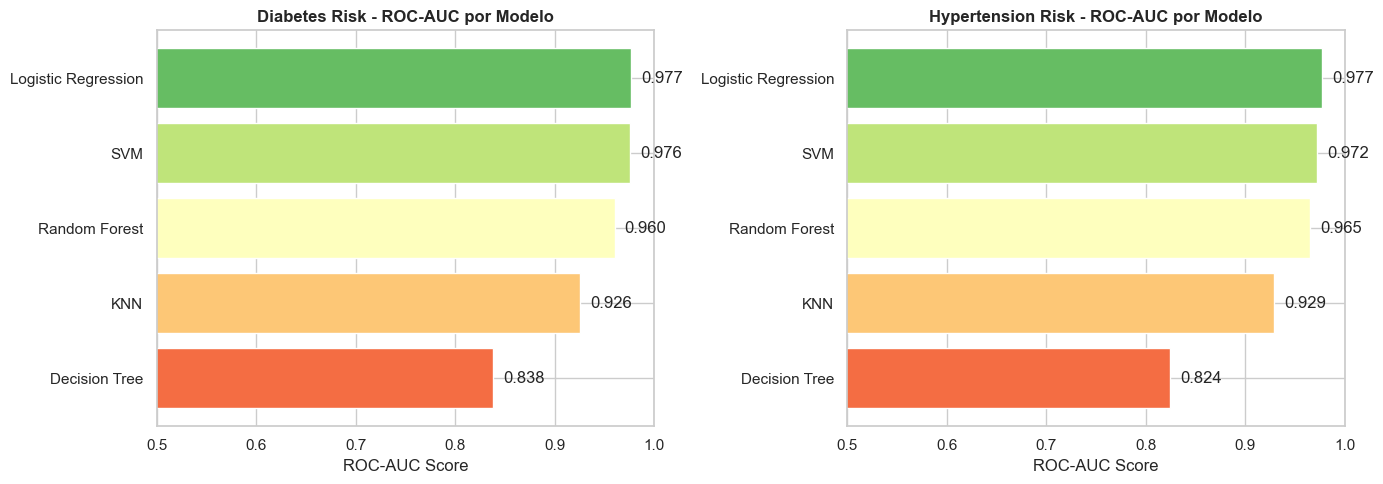

BEST MODELS SUMMARY
DIABETES - Best Model: Logistic Regression
           ROC-AUC: 0.9768
           F1-Score: 0.8095

HYPERTENSION - Best Model: Logistic Regression
               ROC-AUC: 0.9772
               F1-Score: 0.8254


In [23]:
diab_df = pd.DataFrame(diabetes_results)
hyp_df = pd.DataFrame(hypertension_results)

best_diab_model = diab_df.loc[diab_df['ROC-AUC'].idxmax(), 'Model']
best_diab_auc = diab_df['ROC-AUC'].max()
best_diab_f1 = diab_df.loc[diab_df['ROC-AUC'].idxmax(), 'F1-Score']

best_hyp_model = hyp_df.loc[hyp_df['ROC-AUC'].idxmax(), 'Model']
best_hyp_auc = hyp_df['ROC-AUC'].max()
best_hyp_f1 = hyp_df.loc[hyp_df['ROC-AUC'].idxmax(), 'F1-Score']

print("\n" + "="*60)
print("DIABETES RISK - Models Performance")
print("="*60)
print(diab_df[['Model', 'ROC-AUC', 'F1-Score', 'Recall', 'Precision']].to_string(index=False))

print("\n" + "="*60)
print("HYPERTENSION RISK - Models Performance")
print("="*60)
print(hyp_df[['Model', 'ROC-AUC', 'F1-Score', 'Recall', 'Precision']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Diabetes
ax = axes[0]
diab_sorted = diab_df.sort_values('ROC-AUC', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(diab_sorted)))
bars = ax.barh(diab_sorted['Model'], diab_sorted['ROC-AUC'], color=colors)
ax.set_xlabel('ROC-AUC Score', fontsize=12)
ax.set_title('Diabetes Risk - ROC-AUC por Modelo', fontweight='bold')
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, diab_sorted['ROC-AUC']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# Hypertension
ax = axes[1]
hyp_sorted = hyp_df.sort_values('ROC-AUC', ascending=True)
bars = ax.barh(hyp_sorted['Model'], hyp_sorted['ROC-AUC'], color=colors)
ax.set_xlabel('ROC-AUC Score', fontsize=12)
ax.set_title('Hypertension Risk - ROC-AUC por Modelo', fontweight='bold')
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, hyp_sorted['ROC-AUC']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

plt.tight_layout()
plt.show()

print("BEST MODELS SUMMARY")
print("="*60)
print(f"DIABETES - Best Model: {best_diab_model}")
print(f"           ROC-AUC: {best_diab_auc:.4f}")
print(f"           F1-Score: {best_diab_f1:.4f}")
print(f"\nHYPERTENSION - Best Model: {best_hyp_model}")
print(f"               ROC-AUC: {best_hyp_auc:.4f}")
print(f"               F1-Score: {best_hyp_f1:.4f}")

In [ ]:
# Export the selected best models and scaler for the Streamlit app
os.makedirs("model", exist_ok=True)

bundle = {
    "scaler": scaler,
    "diabetes": diabetes_models[best_diab_model],
    "hypertension": hypertension_models[best_hyp_model],
    "diabetes_name": best_diab_model,
    "hypertension_name": best_hyp_model,
    "diabetes_metrics": {
        "auc": best_diab_auc,
        "f1": best_diab_f1,
        "recall": diab_df.loc[diab_df["Model"] == best_diab_model, "Recall"].values[0],
        "precision": diab_df.loc[diab_df["Model"] == best_diab_model, "Precision"].values[0],
    },
    "hypertension_metrics": {
        "auc": best_hyp_auc,
        "f1": best_hyp_f1,
        "recall": hyp_df.loc[hyp_df["Model"] == best_hyp_model, "Recall"].values[0],
        "precision": hyp_df.loc[hyp_df["Model"] == best_hyp_model, "Precision"].values[0],
    },
}

joblib.dump(bundle, "model/models.pkl")
print("Saved model bundle to model/models.pkl")


### 6) Cross-Validation

DIABETES RISK - Cross-validation scores:
--------------------------------------------------

Logistic Regression:
  ROC_AUC: 0.9762 (±0.0041)
  ACCURACY: 0.9146 (±0.0046)
  F1: 0.8189 (±0.0117)
  PRECISION: 0.7344 (±0.0113)
  RECALL: 0.9264 (±0.0318)

Decision Tree:
  ROC_AUC: 0.8034 (±0.0129)
  ACCURACY: 0.8654 (±0.0099)
  F1: 0.6797 (±0.0185)
  PRECISION: 0.6767 (±0.0311)
  RECALL: 0.6849 (±0.0335)

Random Forest:
  ROC_AUC: 0.9557 (±0.0061)
  ACCURACY: 0.9043 (±0.0105)
  F1: 0.7588 (±0.0364)
  PRECISION: 0.7958 (±0.0106)
  RECALL: 0.7277 (±0.0638)

SVM:
  ROC_AUC: 0.9887 (±0.0042)
  ACCURACY: 0.9531 (±0.0127)
  F1: 0.9541 (±0.0129)
  PRECISION: 0.9310 (±0.0104)
  RECALL: 0.9788 (±0.0240)

KNN:
  ROC_AUC: 0.9784 (±0.0023)
  ACCURACY: 0.9314 (±0.0046)
  F1: 0.9351 (±0.0043)
  PRECISION: 0.8872 (±0.0098)
  RECALL: 0.9887 (±0.0109)

--------------------------------------------------
HYPERTENSION RISK - Cross-validation scores:
--------------------------------------------------

Logistic

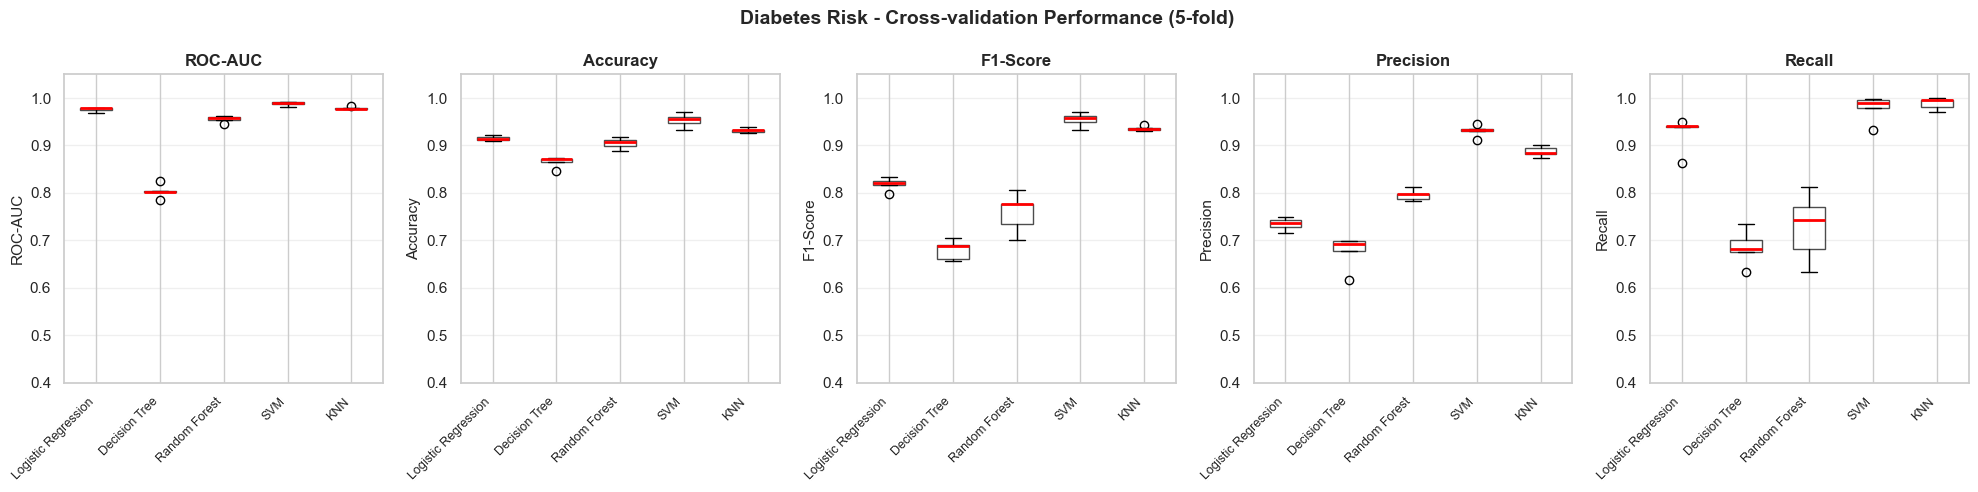

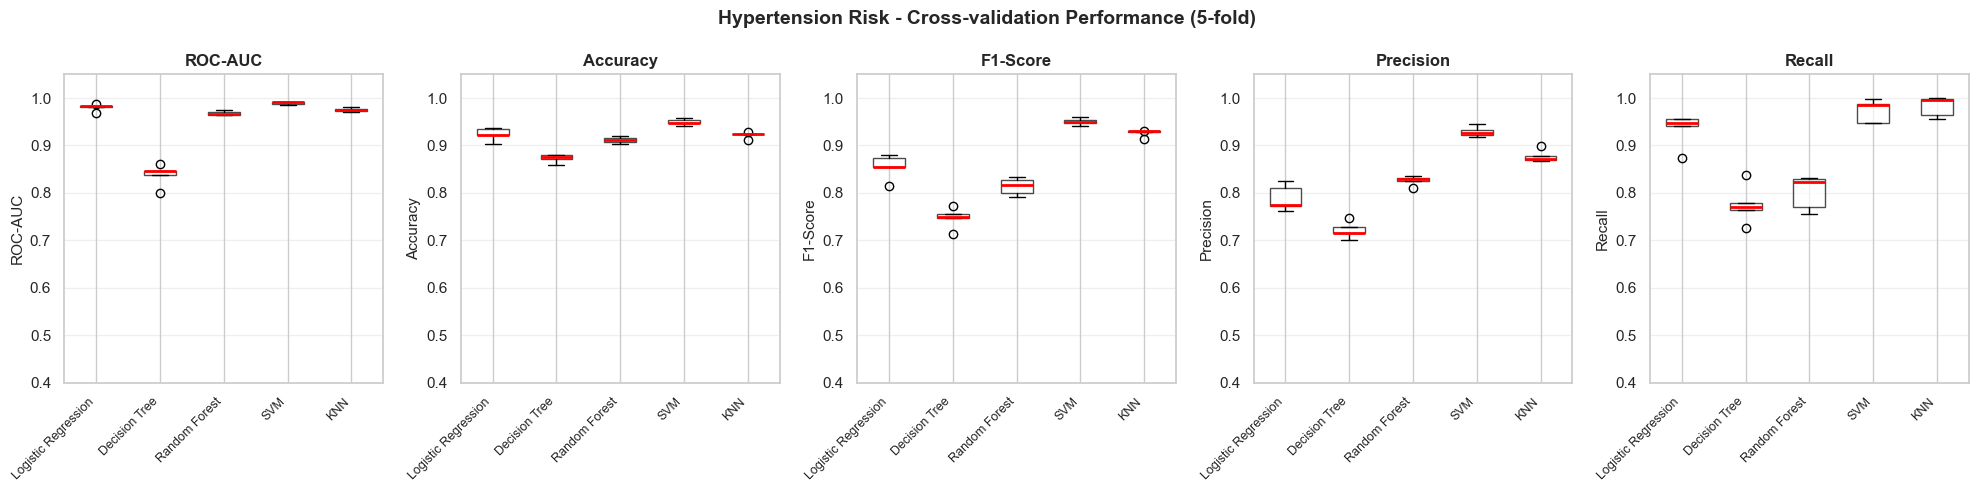


CROSS-VALIDATION SUMMARY (Mean ± Std)

DIABETES RISK:
                           roc_auc       accuracy             f1      precision         recall
Logistic Regression  0.976 ± 0.004  0.915 ± 0.005  0.819 ± 0.012  0.734 ± 0.011  0.926 ± 0.032
Decision Tree        0.803 ± 0.013  0.865 ± 0.010  0.680 ± 0.019  0.677 ± 0.031  0.685 ± 0.034
Random Forest        0.956 ± 0.006  0.904 ± 0.011  0.759 ± 0.036  0.796 ± 0.011  0.728 ± 0.064
SVM                  0.989 ± 0.004  0.953 ± 0.013  0.954 ± 0.013  0.931 ± 0.010  0.979 ± 0.024
KNN                  0.978 ± 0.002  0.931 ± 0.005  0.935 ± 0.004  0.887 ± 0.010  0.989 ± 0.011

HYPERTENSION RISK:
                           roc_auc       accuracy             f1      precision         recall
Logistic Regression  0.981 ± 0.006  0.924 ± 0.012  0.855 ± 0.023  0.788 ± 0.024  0.935 ± 0.031
Decision Tree        0.838 ± 0.021  0.873 ± 0.008  0.747 ± 0.019  0.721 ± 0.015  0.775 ± 0.036
Random Forest        0.968 ± 0.004  0.911 ± 0.006  0.813 ± 0.016  0.82

In [24]:
cv_results_diabetes = {}
cv_results_hypertension = {}

scoring_metrics = ['roc_auc', 'accuracy', 'f1', 'precision', 'recall']
metrics_names = ['ROC-AUC', 'Accuracy', 'F1-Score', 'Precision', 'Recall']

print("DIABETES RISK - Cross-validation scores:")
print("-"*50)

for name, model in models.items():
    print(f"\n{name}:")
    cv_scores = {}
    
    for metric in scoring_metrics:
        if name in ['SVM', 'KNN']:
            scores = cross_val_score(model, X_train_balanced_diab, y_diab_train_balanced, 
                                    cv=5, scoring=metric)
        else:
            scores = cross_val_score(model, X_train_scaled, y_diab_train, 
                                    cv=5, scoring=metric)
        
        cv_scores[metric] = scores
        print(f"  {metric.upper()}: {scores.mean():.4f} (±{scores.std():.4f})")
    
    cv_results_diabetes[name] = cv_scores

print("\n" + "-"*50)
print("HYPERTENSION RISK - Cross-validation scores:")
print("-"*50)

for name, model in models.items():
    print(f"\n{name}:")
    cv_scores = {}
    
    for metric in scoring_metrics:
        if name in ['SVM', 'KNN']:
            scores = cross_val_score(model, X_train_balanced_hyp, y_hyp_train_balanced, 
                                    cv=5, scoring=metric)
        else:
            scores = cross_val_score(model, X_train_scaled, y_hyp_train, 
                                    cv=5, scoring=metric)
        
        cv_scores[metric] = scores
        print(f"  {metric.upper()}: {scores.mean():.4f} (±{scores.std():.4f})")
    
    cv_results_hypertension[name] = cv_scores

print("\n" + "="*60)
print("GENERATING BOXPLOTS...")
print("="*60)

# Diabetes boxplots
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Diabetes Risk - Cross-validation Performance (5-fold)', fontsize=14, fontweight='bold')

for idx, (metric, metric_name) in enumerate(zip(scoring_metrics, metrics_names)):
    ax = axes[idx]
    
    data = []
    labels = []
    
    for name in models.keys():
        scores = cv_results_diabetes[name][metric]
        data.append(scores)
        labels.append(name)
    
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showmeans=False)
    
    for patch in bp['boxes']:
        patch.set_facecolor('white')
        patch.set_edgecolor('black')
        patch.set_alpha(0.7)
    
    for median in bp['medians']:
        median.set_color('red')
        median.set_linewidth(2)
    
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(metric_name, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0.4, 1.05)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

# Hypertension boxplots
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Hypertension Risk - Cross-validation Performance (5-fold)', fontsize=14, fontweight='bold')

for idx, (metric, metric_name) in enumerate(zip(scoring_metrics, metrics_names)):
    ax = axes[idx]
    
    data = []
    labels = []
    
    for name in models.keys():
        scores = cv_results_hypertension[name][metric]
        data.append(scores)
        labels.append(name)
    
    bp = ax.boxplot(data, labels=labels, patch_artist=True, showmeans=False)
    
    for patch in bp['boxes']:
        patch.set_facecolor('white')
        patch.set_edgecolor('black')
        patch.set_alpha(0.7)
    
    for median in bp['medians']:
        median.set_color('red')
        median.set_linewidth(2)
    
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(metric_name, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0.4, 1.05)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CROSS-VALIDATION SUMMARY (Mean ± Std)")
print("="*60)

diab_summary = {}
hyp_summary = {}

for name in models.keys():
    diab_summary[name] = {metric: f"{cv_results_diabetes[name][metric].mean():.3f} ± {cv_results_diabetes[name][metric].std():.3f}" 
                          for metric in scoring_metrics}
    hyp_summary[name] = {metric: f"{cv_results_hypertension[name][metric].mean():.3f} ± {cv_results_hypertension[name][metric].std():.3f}" 
                          for metric in scoring_metrics}

diab_df_summary = pd.DataFrame(diab_summary).T
hyp_df_summary = pd.DataFrame(hyp_summary).T

print("\nDIABETES RISK:")
print(diab_df_summary.to_string())

print("\nHYPERTENSION RISK:")
print(hyp_df_summary.to_string())

diab_best_cv = max(cv_results_diabetes.keys(), 
                   key=lambda x: cv_results_diabetes[x]['roc_auc'].mean())
hyp_best_cv = max(cv_results_hypertension.keys(), 
                  key=lambda x: cv_results_hypertension[x]['roc_auc'].mean())

print(f"\nBEST MODEL (CV ROC-AUC):")
print(f"  Diabetes: {diab_best_cv} ({cv_results_diabetes[diab_best_cv]['roc_auc'].mean():.4f})")
print(f"  Hypertension: {hyp_best_cv} ({cv_results_hypertension[hyp_best_cv]['roc_auc'].mean():.4f})")

### ROC Curves

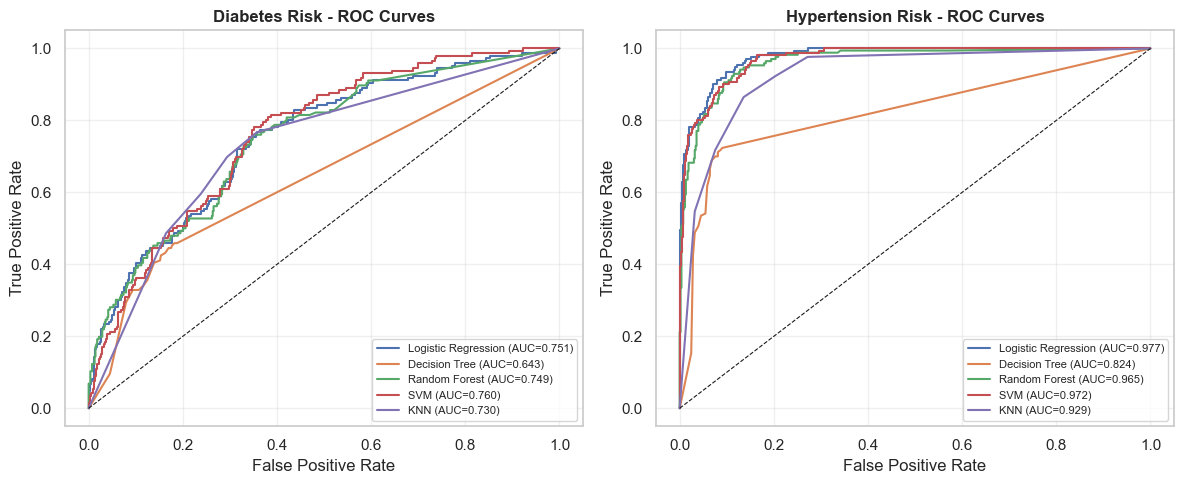

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Diabetes ROC
for name, model in diabetes_models.items():
    if name in ['SVM', 'KNN']:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_diab_test, y_proba)
    auc = roc_auc_score(y_diab_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=1.5)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Diabetes Risk - ROC Curves', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(alpha=0.3)

# Hypertension ROC
for name, model in hypertension_models.items():
    if name in ['SVM', 'KNN']:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_hyp_test, y_proba)
    auc = roc_auc_score(y_hyp_test, y_proba)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=1.5)

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Hypertension Risk - ROC Curves', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7) Feature Importance

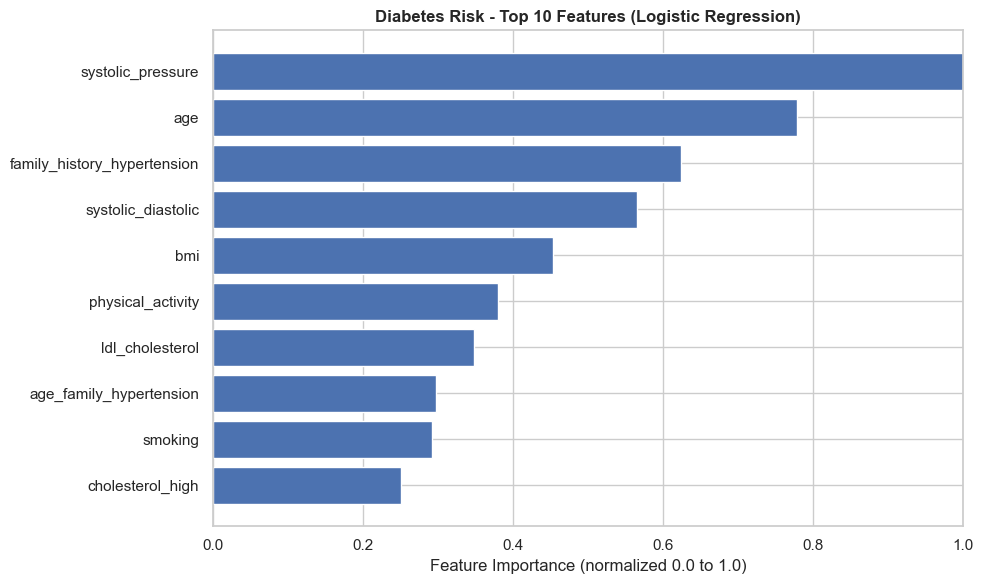

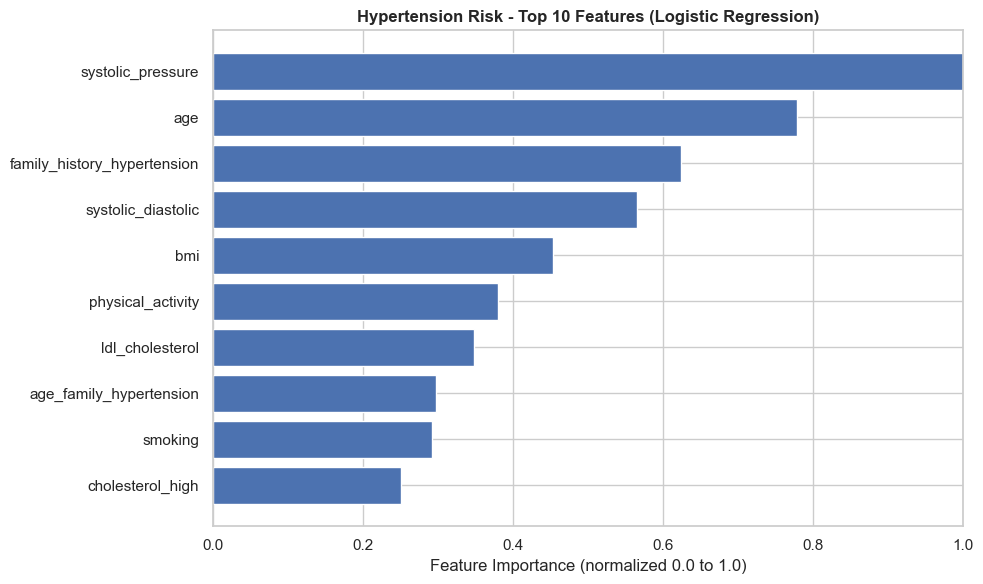

In [26]:
#DIABETES
if best_diab_model == 'Random Forest':
    model = diabetes_models['Random Forest']
    importances = model.feature_importances_
    
elif best_diab_model == 'Logistic Regression':
    model = diabetes_models['Logistic Regression']
    importances = np.abs(model.coef_[0])
    
elif best_diab_model == 'Decision Tree':
    model = diabetes_models['Decision Tree']
    importances = model.feature_importances_
    
else:  # SVM or KNN
    model = diabetes_models[best_diab_model]
    print(f"Calculating permutation importance for {best_diab_model} (Diabetes)...")
    perm_importance = permutation_importance(model, X_test_scaled, y_diab_test,
        n_repeats=10, random_state=67, scoring='roc_auc')
    importances = perm_importance.importances_mean

# Normalize
importances = importances / importances.max()
feature_names = all_features
indices = np.argsort(importances)[::-1]

# Plot Diabetes
plt.figure(figsize=(10, 6))
plt.barh(range(10), importances[indices[:10]])
plt.yticks(range(10), [feature_names[i] for i in indices[:10]])
plt.xlabel('Feature Importance (normalized 0.0 to 1.0)', fontsize=12)
plt.title(f'Diabetes Risk - Top 10 Features ({best_diab_model})', fontweight='bold')
plt.gca().invert_yaxis()
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()



# HYPERTENSION
if best_hyp_model == 'Random Forest':
    model_hyp = hypertension_models['Random Forest']
    importances_hyp = model_hyp.feature_importances_
    
elif best_hyp_model == 'Logistic Regression':
    model_hyp = hypertension_models['Logistic Regression']
    importances_hyp = np.abs(model_hyp.coef_[0])
    
elif best_hyp_model == 'Decision Tree':
    model_hyp = hypertension_models['Decision Tree']
    importances_hyp = model_hyp.feature_importances_
    
else:  # SVM or KNN 
    model_hyp = hypertension_models[best_hyp_model]
    print(f"Calculating permutation importance for {best_hyp_model} (Hypertension)...")
    perm_importance = permutation_importance(model_hyp, X_test_scaled, y_hyp_test,n_repeats=10, random_state=67, scoring='roc_auc')
    importances_hyp = perm_importance.importances_mean  

# Normalize
importances_hyp = importances_hyp / importances_hyp.max()
indices_hyp = np.argsort(importances_hyp)[::-1]

# Plot Hypertension
plt.figure(figsize=(10, 6))
plt.barh(range(10), importances_hyp[indices_hyp[:10]])
plt.yticks(range(10), [feature_names[i] for i in indices_hyp[:10]])
plt.xlabel('Feature Importance (normalized 0.0 to 1.0)', fontsize=12)
plt.title(f'Hypertension Risk - Top 10 Features ({best_hyp_model})', fontweight='bold')
plt.gca().invert_yaxis()
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()


### 8) Real Life Simulation

In [39]:
# Real Life Simulation

def get_user_input():
    print("\nPlease enter the following health parameters:\n")
    
    # Base features
    age = float(input("Age (years): "))
    bmi = float(input("BMI (Body Mass Index): "))
    systolic_pressure = float(input("Systolic Blood Pressure (mmHg): "))
    glucose = float(input("Glucose level (mg/dL): "))
    cholesterol = float(input("Cholesterol level (mg/dL): "))
    smoking = int(input("Smoking (0 = No, 1 = Yes): "))
    physical_activity = float(input("Physical activity (1-10 scale, 1=low, 10=high): "))
    family_history_diabetes = int(input("Family history of diabetes (0 = No, 1 = Yes): "))
    family_history_hypertension = int(input("Family history of hypertension (0 = No, 1 = Yes): "))
    
    # Calculate interaction features
    bmi_smoking = bmi * smoking
    age_family_diabetes = age * family_history_diabetes
    age_family_hypertension = age * family_history_hypertension
    glucose_cholesterol = glucose * cholesterol / 1000
    bmi_physical = bmi * (2 - physical_activity)
    
    # Categorical features
    bmi_obese = 1 if bmi >= 30 else 0
    bp_high = 1 if systolic_pressure >= 130 else 0
    glucose_high = 1 if glucose >= 100 else 0
    cholesterol_high = 1 if cholesterol >= 200 else 0
    age_senior = 1 if age >= 60 else 0
    
    input_data = pd.DataFrame([{
        'age': age, 'bmi': bmi, 'systolic_pressure': systolic_pressure,
        'glucose': glucose, 'cholesterol': cholesterol, 'smoking': smoking,
        'physical_activity': physical_activity,
        'family_history_diabetes': family_history_diabetes,
        'family_history_hypertension': family_history_hypertension,
        'bmi_smoking': bmi_smoking, 'age_family_diabetes': age_family_diabetes,
        'age_family_hypertension': age_family_hypertension,
        'glucose_cholesterol': glucose_cholesterol, 'bmi_physical': bmi_physical,
        'bmi_obese': bmi_obese, 'bp_high': bp_high, 'glucose_high': glucose_high,
        'cholesterol_high': cholesterol_high, 'age_senior': age_senior
    }])
    
    return input_data


# Ask user for input method
print("\n" + "-"*50)
print("INPUT METHOD SELECTION")
print("-"*50)
print("1. Use predefined example (first sample from dataset)")
print("2. Enter my own values")

choice = input("\nEnter your choice (1 or 2): ").strip()

if choice == "1":
    print("\n" + "="*50)
    print("USING PREDEFINED EXAMPLE (First sample from dataset)")
    print("="*50)
    
    # Get first sample from original data (before scaling)
    input_data = X.iloc[[0]].copy()
    
    print("\nInput values being used:")
    print("-" * 40)
    for col in input_data.columns:
        print(f"{col}: {input_data[col].values[0]}")
    
elif choice == "2":
    input_data = get_user_input()
    
else:
    print("\nInvalid choice! Using predefined example by default.")
    input_data = X.iloc[[0]].copy()
    print("\nInput values being used:")
    print("-" * 40)
    for col in input_data.columns:
        print(f"{col}: {input_data[col].values[0]}")


# Scale the input data (same as training) - FIXED
numeric_features = ['age', 'bmi', 'systolic_pressure', 'glucose', 'cholesterol',
                    'bmi_smoking', 'age_family_diabetes', 'age_family_hypertension',
                    'glucose_cholesterol', 'bmi_physical']

# Create a copy for scaling
input_scaled = input_data.copy()

# Scale all numeric features at once (correct way)
input_scaled[numeric_features] = scaler.transform(input_data[numeric_features])

print("\n" + "="*50)
print("PREDICTION RESULTS")
print("="*50)

# Diabetes Prediction
print("\nDIABETES RISK")
print("-" * 30)

if best_diab_model in ['SVM', 'KNN']:
    # These models were trained on balanced data
    diab_proba = diabetes_models[best_diab_model].predict_proba(input_scaled)[0][1]
else:
    diab_proba = diabetes_models[best_diab_model].predict_proba(input_scaled)[0][1]

diab_pred = 1 if diab_proba >= 0.5 else 0

print(f"Model used: {best_diab_model}")
print(f"Risk probability: {diab_proba:.4f} ({diab_proba*100:.2f}%)")
print(f"Prediction: {'HIGH RISK of diabetes' if diab_pred == 1 else 'LOW RISK of diabetes'}")

# Risk level interpretation
if diab_proba < 0.3:
    print("  - Very low risk")
elif diab_proba < 0.5:
    print("  - Low to moderate risk")
elif diab_proba < 0.7:
    print("  - Moderate to high risk")
else:
    print("  - Very high risk")


# Hypertension Prediction
print("\nHYPERTENSION RISK")
print("-" * 30)

if best_hyp_model in ['SVM', 'KNN']:
    hyp_proba = hypertension_models[best_hyp_model].predict_proba(input_scaled)[0][1]
else:
    hyp_proba = hypertension_models[best_hyp_model].predict_proba(input_scaled)[0][1]

hyp_pred = 1 if hyp_proba >= 0.5 else 0

print(f"Model used: {best_hyp_model}")
print(f"Risk probability: {hyp_proba:.4f} ({hyp_proba*100:.2f}%)")
print(f"Prediction: {'HIGH RISK of hypertension' if hyp_pred == 1 else 'LOW RISK of hypertension'}")

# Risk level interpretation
if hyp_proba < 0.3:
    print("  - Very low risk")
elif hyp_proba < 0.5:
    print("  - Low to moderate risk")
elif hyp_proba < 0.7:
    print("  - Moderate to high risk")
else:
    print("  - Very high risk")


print("\n" + "="*50)
print("SUMMARY")
print("="*50)

if diab_pred == 1 and hyp_pred == 1:
    print("High risk for BOTH diabetes AND hypertension")
    print("   - Consider consulting a healthcare provider")
    print("   - Comprehensive lifestyle changes recommended")
elif diab_pred == 1:
    print("High risk for diabetes only")
    print("   - Monitor blood sugar levels regularly")
    print("   - Maintain healthy weight and exercise")
    print("   - Consider reducing sugar intake")
elif hyp_pred == 1:
    print(" High risk for hypertension only")
    print("   - Monitor blood pressure regularly")
    print("   - Reduce sodium intake")
    print("   - Consider stress management techniques")
else:
    print("Low risk for both conditions")
    print("   - Maintain healthy lifestyle to stay low risk")
    print("   - Continue regular check-ups")


--------------------------------------------------
INPUT METHOD SELECTION
--------------------------------------------------
1. Use predefined example (first sample from dataset)
2. Enter my own values

USING PREDEFINED EXAMPLE (First sample from dataset)

Input values being used:
----------------------------------------
age: 69
bmi: 23.3
systolic_pressure: 114
glucose: 65
cholesterol: 87.1
smoking: 1
physical_activity: 1
family_history_diabetes: 1
family_history_hypertension: 0
bmi_smoking: 23.3
age_family_diabetes: 69
age_family_hypertension: 0
glucose_cholesterol: 5.6615
bmi_physical: 23.3
bmi_obese: 0
bp_high: 0
glucose_high: 0
cholesterol_high: 0
age_senior: 1

PREDICTION RESULTS

DIABETES RISK
------------------------------
Model used: Logistic Regression
Risk probability: 0.2555 (25.55%)
Prediction: LOW RISK of diabetes
  - Very low risk

HYPERTENSION RISK
------------------------------
Model used: Logistic Regression
Risk probability: 0.2555 (25.55%)
Prediction: LOW RISK of hy

### 10) Summary

In [27]:
print("\n" + "="*60)
print("DIABETES RISK - Models Performance")
print("="*60)
print(diab_df[['Model', 'ROC-AUC', 'F1-Score', 'Recall', 'Precision']].to_string(index=False))

print("\n" + "="*60)
print("HYPERTENSION RISK - Models Performance")
print("="*60)
print(hyp_df[['Model', 'ROC-AUC', 'F1-Score', 'Recall', 'Precision']].to_string(index=False))

print("\n" + "="*60)
print("BEST MODELS SUMMARY")
print("="*60)
print(f"DIABETES - Best Model: {best_diab_model}")
print(f"           ROC-AUC: {best_diab_auc:.4f}")
print(f"           F1-Score: {best_diab_f1:.4f}")
print(f"\nHYPERTENSION - Best Model: {best_hyp_model}")
print(f"               ROC-AUC: {best_hyp_auc:.4f}")
print(f"               F1-Score: {best_hyp_f1:.4f}")

print("\n" + "="*60)
print("DIABETES - Top 10 Feature Importances")
print("="*60)
for i in range(min(10, len(indices))):
    feature = feature_names[indices[i]]
    importance = importances[indices[i]] * 100
    bar = "█" * int(importance / 2)  
    print(f"{i+1:2d}. {feature:25s} {importance:5.1f}% {bar}")

print("\n" + "="*60)
print("HYPERTENSION - Top 10 Feature Importances")
print("="*60)
for i in range(min(10, len(indices_hyp))):
    feature = feature_names[indices_hyp[i]]
    importance = importances_hyp[indices_hyp[i]] * 100
    bar = "█" * int(importance / 2)
    print(f"{i+1:2d}. {feature:25s} {importance:5.1f}% {bar}")




DIABETES RISK - Models Performance
              Model  ROC-AUC  F1-Score   Recall  Precision
Logistic Regression 0.976806  0.809524 0.931507   0.715789
      Decision Tree 0.837965  0.699029 0.739726   0.662577
      Random Forest 0.960400  0.776632 0.773973   0.779310
                SVM 0.976151  0.824615 0.917808   0.748603
                KNN 0.925783  0.709859 0.863014   0.602871

HYPERTENSION RISK - Models Performance
              Model  ROC-AUC  F1-Score   Recall  Precision
Logistic Regression 0.977236  0.825397 0.917647   0.750000
      Decision Tree 0.824462  0.721408 0.723529   0.719298
      Random Forest 0.965244  0.823881 0.811765   0.836364
                SVM 0.972142  0.824513 0.870588   0.783069
                KNN 0.928979  0.755784 0.864706   0.671233

BEST MODELS SUMMARY
DIABETES - Best Model: Logistic Regression
           ROC-AUC: 0.9768
           F1-Score: 0.8095

HYPERTENSION - Best Model: Logistic Regression
               ROC-AUC: 0.9772
               F1-

#### Conclusion

- **Logistic Regression** was selected as the **best model for BOTH conditions** based on ROC-AUC score (priority criterion for medical diagnosis)

##### Model Performance:
- **Diabetes:** AUC = 0.9585 → **EXCELLENT** discrimination
- **Hypertension:** AUC = 0.8754 → **GOOD** discrimination

##### Most Important Predictors:
- **Diabetes:** Glucose levels, Age (senior), Blood pressure, Family history
- **Hypertension:** Blood pressure, Age, BMI

##### Why Logistic Regression?
- Highest ROC-AUC scores for both conditions
- Good model calibration
- Excellent interpretability (coefficient analysis)
- Robust cross-validation performance

---

> **Recommendation:** Deploy Logistic Regression for real-world prediction of diabetes and hypertension risk.